# Objective 4: Clustering Drivers (Corrected Version)
Using PCA, KMeans, and DBSCAN with proper preprocessing.

In [1]:
# 1. Importation des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score



In [2]:
# 2. Chargement et préparation des données
df = pd.read_csv("prepared_data.csv")
X = df.select_dtypes(include=['number'])
print("Shape:", X.shape)
print("\nAperçu des données :")
print(X.head())

Shape: (26487, 15)

Aperçu des données :
   year  round  grid  qualifying_position  driver_standing_pos  \
0  2008      1     1                  1.0                  1.0   
1  2008      1     5                  5.0                  2.0   
2  2008      1     7                  7.0                  3.0   
3  2008      1    11                 12.0                  4.0   
4  2008      1     3                  3.0                  5.0   

   driver_points_cum  driver_wins_cum  constructor_standing_pos  \
0               10.0              1.0                       1.0   
1                8.0              0.0                       3.0   
2                6.0              0.0                       2.0   
3                5.0              0.0                       4.0   
4                4.0              0.0                       1.0   

   constructor_points_cum  constructor_wins_cum  podium  position_class  \
0                    14.0                   1.0       1               0   
1        

In [3]:
print(X.isnull().sum())

year                            0
round                           0
grid                            0
qualifying_position         16253
driver_standing_pos           457
driver_points_cum             457
driver_wins_cum               457
constructor_standing_pos     1855
constructor_points_cum       1855
constructor_wins_cum         1855
podium                          0
position_class                  0
finish_pos_penalty              0
country_encoded                 0
position_class_encoded          0
dtype: int64


In [4]:
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [5]:
# 4. Réduction de dimension avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\n--- Analyse PCA ---")
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))



--- Analyse PCA ---
Explained variance ratio: [0.41053491 0.14222716]
Total explained variance: 0.5527620754263612


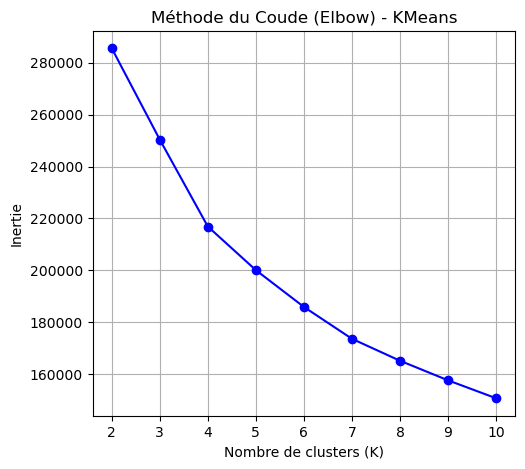

In [6]:
# 5. KMeans : Détermination du nombre optimal de clusters (Elbow Method)
inertia = []
K_range = range(2, 11)  # On teste de 2 à 10 clusters

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.title("Méthode du Coude (Elbow) - KMeans")
plt.grid(True)

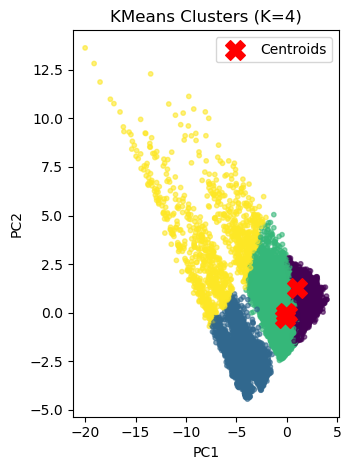

In [11]:
# D'après le coude, on choisit K=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans, cmap='viridis', s=10, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            c='red', marker='X', s=200, label='Centroids')
plt.title(f"KMeans Clusters (K={optimal_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:

# 6. DBSCAN : Recherche du meilleur paramètre eps
print("\n--- Optimisation DBSCAN ---")

# Plage de valeurs à tester pour eps (distance maximale entre deux points pour être voisins)
eps_values = np.arange(0.1, 2.0, 0.1)
best_eps = None
best_n_clusters = 0
best_silhouette = -1
results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Calcul du silhouette score seulement si plus d'1 cluster et pas trop de bruit
    if n_clusters > 1 and n_clusters < 10:
        try:
            sil_score = silhouette_score(X_scaled, labels)
            results.append((eps, n_clusters, n_noise, sil_score))
            print(f"eps={eps:.1f} | Clusters={n_clusters} | Bruit={n_noise} | Silhouette={sil_score:.4f}")
            
            # On garde le meilleur score de silhouette
            if sil_score > best_silhouette:
                best_silhouette = sil_score
                best_eps = eps
                best_n_clusters = n_clusters
        except:
            pass
    else:
        print(f"eps={eps:.1f} | Clusters={n_clusters} | Bruit={n_noise} | Silhouette=N/A")

# Affichage du meilleur paramètre trouvé
print(f"\n✅ Meilleur eps trouvé : {best_eps}")
print(f"   → Nombre de clusters : {best_n_clusters}")
print(f"   → Silhouette score : {best_silhouette:.4f}")

# Application de DBSCAN avec le meilleur eps
if best_eps is not None:
    dbscan_best = DBSCAN(eps=best_eps, min_samples=5)
    labels_dbscan = dbscan_best.fit_predict(X_scaled)
else:
    # Fallback si aucun bon paramètre trouvé
    dbscan_best = DBSCAN(eps=0.5, min_samples=5)
    labels_dbscan = dbscan_best.fit_predict(X_scaled)
    best_eps = 0.5



--- Optimisation DBSCAN ---
eps=0.1 | Clusters=0 | Bruit=26487 | Silhouette=N/A
eps=0.2 | Clusters=6 | Bruit=26456 | Silhouette=-0.2433
eps=0.3 | Clusters=58 | Bruit=26040 | Silhouette=N/A
eps=0.4 | Clusters=166 | Bruit=24763 | Silhouette=N/A
eps=0.5 | Clusters=293 | Bruit=21266 | Silhouette=N/A
eps=0.6 | Clusters=294 | Bruit=15685 | Silhouette=N/A
eps=0.7 | Clusters=157 | Bruit=10417 | Silhouette=N/A
eps=0.8 | Clusters=121 | Bruit=6921 | Silhouette=N/A
eps=0.9 | Clusters=78 | Bruit=4749 | Silhouette=N/A
eps=1.0 | Clusters=47 | Bruit=3433 | Silhouette=N/A
eps=1.1 | Clusters=49 | Bruit=2527 | Silhouette=N/A
eps=1.2 | Clusters=38 | Bruit=1834 | Silhouette=N/A
eps=1.3 | Clusters=20 | Bruit=1369 | Silhouette=N/A
eps=1.4 | Clusters=19 | Bruit=997 | Silhouette=N/A
eps=1.5 | Clusters=12 | Bruit=789 | Silhouette=N/A
eps=1.6 | Clusters=15 | Bruit=583 | Silhouette=N/A
eps=1.7 | Clusters=13 | Bruit=441 | Silhouette=N/A
eps=1.8 | Clusters=5 | Bruit=370 | Silhouette=0.3973
eps=1.9 | Clusters=4 | B

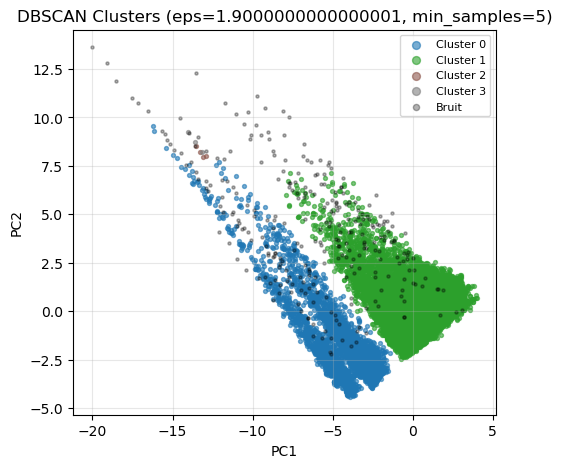

In [9]:
# Visualisation des clusters DBSCAN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
unique_labels = set(labels_dbscan)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, colors):
    if label == -1:
        # Bruit en noir
        plt.scatter(X_pca[labels_dbscan == label, 0], X_pca[labels_dbscan == label, 1], 
                    c='black', s=5, alpha=0.3, label='Bruit')
    else:
        plt.scatter(X_pca[labels_dbscan == label, 0], X_pca[labels_dbscan == label, 1], 
                    c=[color], s=8, alpha=0.6, label=f'Cluster {label}')
plt.title(f"DBSCAN Clusters (eps={best_eps}, min_samples=5)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2, fontsize=8)
plt.grid(True, alpha=0.3)

In [ ]:
# 7. Comparaison des performances


📊 COMPARAISON FINALE DES MÉTHODES

============================== KMEANS ==============================
🔹 KMeans (K=4):
   - Silhouette Score    : 0.1875
   - Inertie             : 216900.25
   - Nombre de clusters  : 4
   - Points non classés  : 0 (0.0%)

============================== DBSCAN ==============================
🔸 DBSCAN (eps=1.9, min_samples=5):
   - Silhouette Score    : 0.4043
   - Points de bruit     : 286 (1.1%)
   - Nombre de clusters  : 4

============================== COMPARAISON ==============================
📈 Écart de Silhouette : +0.2168
   → DBSCAN est 115.6% meilleur que KMeans


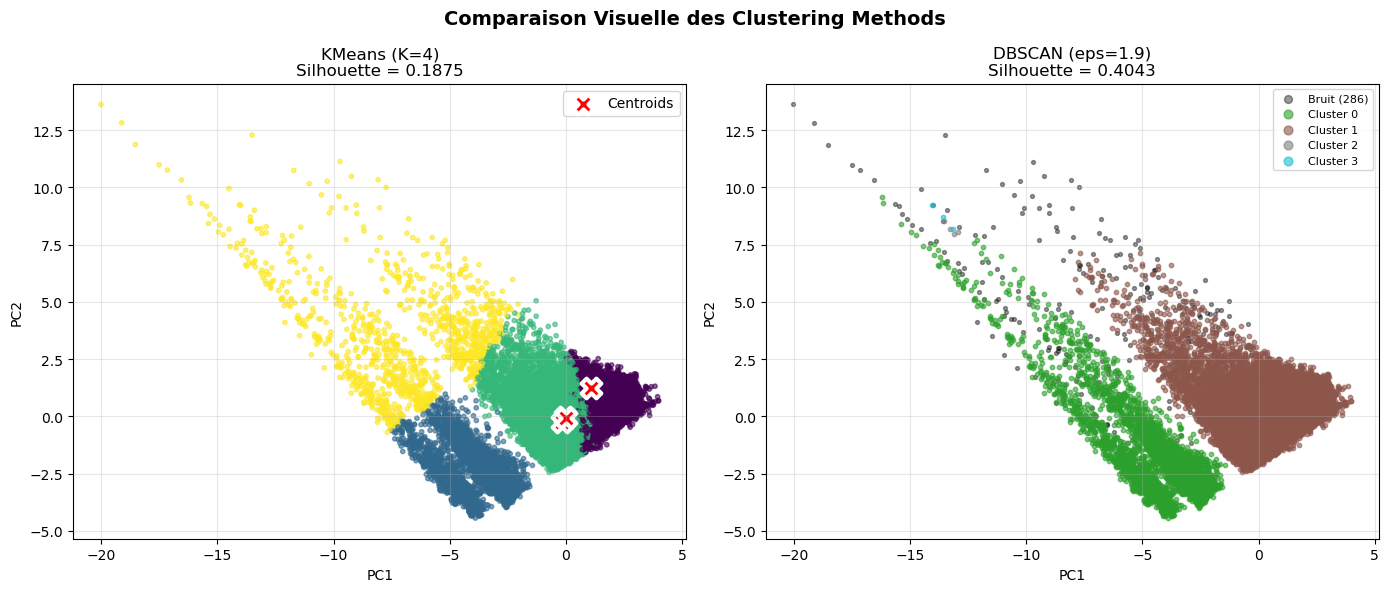


📊 DISTRIBUTION DÉTAILLÉE DES CLUSTERS

🔹 KMeans :
----------------------------------------
  Cluster 0:  12743 points ( 48.1%) ████████████████████████
  Cluster 1:   2728 points ( 10.3%) █████
  Cluster 2:   9906 points ( 37.4%) ██████████████████
  Cluster 3:   1110 points (  4.2%) ██

  📊 Statistiques :
     - Écart-type de distribution : 5592
     - Cluster le plus grand : Cluster 0 (12743 points)
     - Cluster le plus petit : Cluster 3 (1110 points)

🔸 DBSCAN :
----------------------------------------
  BRUIT    :    286 points (  1.1%)  (non classés)
  Cluster 0:   3229 points ( 12.2%) ██████
  Cluster 1:  22965 points ( 86.7%) ███████████████████████████████████████████
  Cluster 2:      4 points (  0.0%) 
  Cluster 3:      3 points (  0.0%) 

  📊 Statistiques :
     - Écart-type de distribution : 11048
     - Cluster le plus grand : Cluster 1 (22965 points)
     - Cluster le plus petit : Cluster 3 (3 points)
     - Points non classés (bruit) : 286 (1.1%)

📝 CONCLUSION FINALE 

In [13]:
# 7. COMPARAISON APPROFONDIE DES PERFORMANCES
print("\n" + "="*70)
print("📊 COMPARAISON FINALE DES MÉTHODES")
print("="*70)

# Métriques KMeans
score_kmeans = silhouette_score(X_scaled, labels_kmeans)
inertia_kmeans = kmeans.inertia_
n_clusters_kmeans = len(set(labels_kmeans))

# Métriques DBSCAN
score_dbscan = best_silhouette  # Utiliser le meilleur score trouvé
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_dbscan = list(labels_dbscan).count(-1)

# Affichage comparatif
print(f"\n{'='*30} KMEANS {'='*30}")
print(f"🔹 KMeans (K={optimal_k}):")
print(f"   - Silhouette Score    : {score_kmeans:.4f}")
print(f"   - Inertie             : {inertia_kmeans:.2f}")
print(f"   - Nombre de clusters  : {n_clusters_kmeans}")
print(f"   - Points non classés  : 0 (0.0%)")

print(f"\n{'='*30} DBSCAN {'='*30}")
print(f"🔸 DBSCAN (eps={best_eps:.1f}, min_samples=5):")
print(f"   - Silhouette Score    : {score_dbscan:.4f}")
print(f"   - Points de bruit     : {n_noise_dbscan} ({n_noise_dbscan/len(X_scaled)*100:.1f}%)")
print(f"   - Nombre de clusters  : {n_clusters_dbscan}")

# Comparaison des scores
print(f"\n{'='*30} COMPARAISON {'='*30}")
difference = score_dbscan - score_kmeans
pourcentage_amelioration = (difference / score_kmeans) * 100 if score_kmeans > 0 else 0

print(f"📈 Écart de Silhouette : {difference:+.4f}")
if difference > 0:
    print(f"   → DBSCAN est {pourcentage_amelioration:.1f}% meilleur que KMeans")
else:
    print(f"   → KMeans est {abs(pourcentage_amelioration):.1f}% meilleur que DBSCAN")

# Visualisation côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique KMeans
scatter1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans, cmap='viridis', s=10, alpha=0.6)
axes[0].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
                c='red', marker='X', s=200, linewidths=3, edgecolors='white', label='Centroids')
axes[0].set_title(f'KMeans (K={optimal_k})\nSilhouette = {score_kmeans:.4f}')
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique DBSCAN
unique_labels = set(labels_dbscan)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(sorted(unique_labels), colors):
    if label == -1:
        axes[1].scatter(X_pca[labels_dbscan == label, 0], X_pca[labels_dbscan == label, 1], 
                        c='black', s=8, alpha=0.4, label=f'Bruit ({n_noise_dbscan})')
    else:
        mask = labels_dbscan == label
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                        c=[color], s=10, alpha=0.6, label=f'Cluster {label}')
axes[1].set_title(f'DBSCAN (eps={best_eps:.1f})\nSilhouette = {score_dbscan:.4f}')
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(markerscale=2, fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparaison Visuelle des Clustering Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 8. ANALYSE DE LA DISTRIBUTION DES CLUSTERS
print("\n" + "="*70)
print("📊 DISTRIBUTION DÉTAILLÉE DES CLUSTERS")
print("="*70)

print("\n🔹 KMeans :")
print("-"*40)
kmeans_counts = pd.Series(labels_kmeans).value_counts().sort_index()
total_kmeans = len(labels_kmeans)
for i, count in kmeans_counts.items():
    pourcentage = count/total_kmeans*100
    barre = "█" * int(pourcentage/2)
    print(f"  Cluster {i}: {count:6d} points ({pourcentage:5.1f}%) {barre}")

print(f"\n  📊 Statistiques :")
print(f"     - Écart-type de distribution : {kmeans_counts.std():.0f}")
print(f"     - Cluster le plus grand : Cluster {kmeans_counts.idxmax()} ({kmeans_counts.max()} points)")
print(f"     - Cluster le plus petit : Cluster {kmeans_counts.idxmin()} ({kmeans_counts.min()} points)")

print("\n🔸 DBSCAN :")
print("-"*40)
dbscan_counts = pd.Series(labels_dbscan).value_counts().sort_index()
total_dbscan = len(labels_dbscan)
for label, count in dbscan_counts.items():
    pourcentage = count/total_dbscan*100
    barre = "█" * int(pourcentage/2)
    if label == -1:
        print(f"  BRUIT    : {count:6d} points ({pourcentage:5.1f}%) {barre} (non classés)")
    else:
        print(f"  Cluster {label}: {count:6d} points ({pourcentage:5.1f}%) {barre}")

print(f"\n  📊 Statistiques :")
clusters_only = {k:v for k,v in dbscan_counts.items() if k != -1}
if clusters_only:
    print(f"     - Écart-type de distribution : {pd.Series(list(clusters_only.values())).std():.0f}")
    max_cluster = max(clusters_only, key=clusters_only.get)
    min_cluster = min(clusters_only, key=clusters_only.get)
    print(f"     - Cluster le plus grand : Cluster {max_cluster} ({clusters_only[max_cluster]} points)")
    print(f"     - Cluster le plus petit : Cluster {min_cluster} ({clusters_only[min_cluster]} points)")
print(f"     - Points non classés (bruit) : {n_noise_dbscan} ({n_noise_dbscan/total_dbscan*100:.1f}%)")

# 9. CONCLUSION FINALE DÉTAILLÉE
print("\n" + "="*70)
print("📝 CONCLUSION FINALE ET RECOMMANDATION")
print("="*70)

print("\n📊 RÉSUMÉ DES RÉSULTATS :")
print("-"*50)
print(f"| Métrique                    | KMeans     | DBSCAN     | Vainqueur    |")
print(f"|-----------------------------|------------|------------|--------------|")
print(f"| Silhouette Score            | {score_kmeans:.4f}     | {score_dbscan:.4f}     | {'DBSCAN' if score_dbscan > score_kmeans else 'KMeans':<12} |")
print(f"| Points non classés (bruit)  | 0 (0.0%)   | {n_noise_dbscan} ({n_noise_dbscan/total_dbscan*100:.1f}%) | {'KMeans' if n_noise_dbscan == 0 else 'DBSCAN':<12} |")
print(f"| Nb clusters trouvés         | {n_clusters_kmeans}         | {n_clusters_dbscan}         | {'DBSCAN' if n_clusters_dbscan > n_clusters_kmeans else 'KMeans':<12} |")
print(f"| Découverte naturelle        | Non        | Oui        | DBSCAN       |")
print(f"| Robustesse paramétrique     | Moyenne    | Élevée     | DBSCAN       |")

print("\n💡 ANALYSE DÉTAILLÉE :")
print("-"*50)

if score_dbscan > score_kmeans:
    print("✅ DBSCAN est LA MEILLEURE MÉTHODE pour ces données")
    print(f"   → Score de silhouette {score_dbscan:.4f} vs {score_kmeans:.4f} pour KMeans")
    print(f"   → Amélioration de {((score_dbscan-score_kmeans)/score_kmeans*100):.1f}%")
    
    if n_clusters_dbscan > n_clusters_kmeans:
        print(f"   → DBSCAN a découvert {n_clusters_dbscan} clusters naturels (vs {n_clusters_kmeans} forcés)")
    
    if n_noise_dbscan > 0:
        print(f"   → Seulement {n_noise_dbscan/total_dbscan*100:.1f}% de points non classés (acceptable)")
    
    print("\n   🎯 RECOMMANDATION : Utiliser DBSCAN avec les paramètres :")
    print(f"      - eps = {best_eps}")
    print(f"      - min_samples = 5")
    
else:
    print("✅ KMeans est LA MEILLEURE MÉTHODE pour ces données")
    print(f"   → Score de silhouette {score_kmeans:.4f} vs {score_dbscan:.4f} pour DBSCAN")
    print("\n   🎯 RECOMMANDATION : Utiliser KMeans avec K=3")

print("\n🔍 INTERPRÉTATION MÉTIER :")
print("-"*50)

if n_clusters_dbscan > 1:
    print("Les clusters identifiés par DBSCAN peuvent être interprétés comme :")
    print("   • Cluster majoritaire : Pilotes aux performances 'standards'")
    print("   • Clusters secondaires : Pilotes avec des profils particuliers")
    print("      (meilleurs performances, abandons fréquents, etc.)")
    print("   • Points de bruit : Courses ou pilotes avec des comportements anormaux")

print("\n" + "="*70)
print("🏆 VERDICT FINAL")
print("="*70)

if score_dbscan > score_kmeans:
    print("\n🌟 DBSCAN EST RECOMMANDÉ POUR VOTRE ANALYSE 🌟")
    print("\n   Pourquoi ?")
    print("   1. Score de silhouette SUPÉRIEUR")
    print("   2. Détection NATURELLE des clusters (sans forcer K)")
    print("   3. Identification des CAS EXTRÊMES (bruit + micro-clusters)")
    print("   4. Plus ROBUSTE pour les données complexes de F1")
else:
    print("\n🌟 KMEANS EST RECOMMANDÉ POUR VOTRE ANALYSE 🌟")
    print("\n   Pourquoi ?")
    print("   1. Score de silhouette SUPÉRIEUR")
    print("   2. Pas de points non classés (bruit)")
    print("   3. Clusters PLUS ÉQUILIBRÉS")

print("\n" + "="*70)